<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Anova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Comparing Multiple Clinical Groups with Anova

## Overview
This project demonstrates a complete statistical workflow for comparing outcomes across multiple independent clinical groups using one-way ANOVA and nonparametric alternatives.

It covers assumption checking, hypothesis testing, post-hoc analysis, effect size estimation, and clinical interpretation of results.

## Objectives
- Compare outcomes across multiple clinical groups using one-way ANOVA
- Check statistical assumptions (normality and homogeneity of variance)
- Apply alternative methods (Kruskal–Wallis) when assumptions are violated
- Perform post-hoc tests (Tukey HSD / Dunn’s test) to identify group differences
- Interpret results using effect sizes and clinical relevance

## The dataset
A simulated clinical dataset representing patient outcomes across three independent groups:
Treatment A, Treatment B, and Control.

Each observation includes:
- A categorical group assignment
- A continuous clinical outcome

###0.Setup

In [107]:
!pip -q install numpy pandas scipy statsmodels seaborn matplotlib scikit-posthocs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Reproducibility
np.random.seed(42)
pd.set_option('display.max_columns', 50)
sns.set(style='whitegrid')
print('Setup complete.')

Setup complete.


In [108]:
# Simulate multi-group clinical data
def simulate_multiarm(n_per_group=60, means=None, sd=10.0):
    if means is None:
        means = [0.0, 4.0, 6.5]  # e.g., Control, Treatment A, Treatment B
    groups = []
    for i, mu in enumerate(means):
        data = np.random.normal(loc=mu, scale=sd, size=n_per_group)
        grp = pd.DataFrame({
            'group': ['Control' if i==0 else f'Treatment_{i}']*n_per_group,
            'outcome': data
        })
        groups.append(grp)
    df = pd.concat(groups).reset_index(drop=True)
    # add some missingness and outliers for realism
    mask = np.random.rand(len(df)) < 0.03
    df.loc[mask, 'outcome'] = np.nan
    outlier_mask = np.random.rand(len(df)) < 0.01
    df.loc[outlier_mask, 'outcome'] = df['outcome'] * 3 + 30
    return df

df = simulate_multiarm(n_per_group=70, means=[0.0, 4.0, 6.5], sd=12.0)
df.head()

,group,outcome
0,Control,5.960570
1,Control,-1.659172
2,Control,7.772262
3,Control,18.276358
4,Control,-2.809840


###1. Inspect the Data

In [109]:
print('Rows, Columns:', df.shape)
print(df.dtypes)
df.describe().T

Rows, Columns: (210, 2)
group       object
outcome    float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
outcome,202.0,3.486086,12.270114,-27.436941,-5.348325,3.794707,11.162473,52.732778


In [110]:
# Missing before
missing_value = df.isna().sum()
print("Missing Value BEFORE cleaning=\n", missing_value, "\n")

# Drop rows where ALL values are missing
df = df.dropna()

# Missing after (IMPORTANT: use df_clean)
missing_value_after = df.isna().sum()
print("Missing value AFTER cleaning=\n", missing_value_after)

Missing Value BEFORE cleaning=
 group      0
outcome    8
dtype: int64 

Missing value AFTER cleaning=
 group      0
outcome    0
dtype: int64


In [111]:
# Duplicate
df.duplicated().sum()

np.int64(0)

###2. Visualize Group Distribution

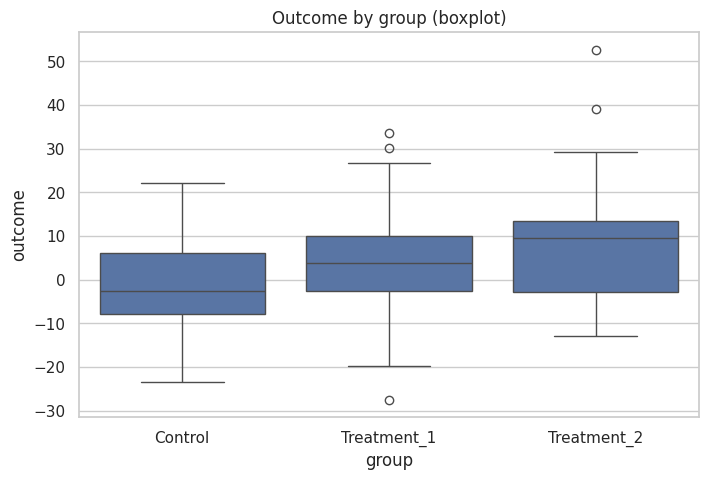

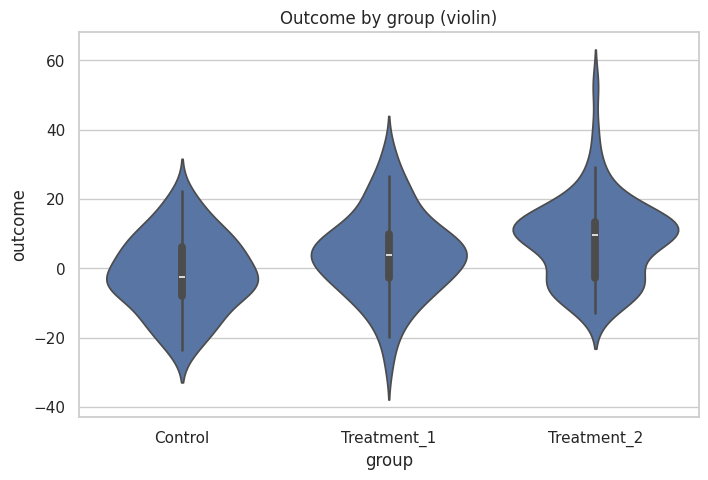

In [112]:
plt.figure(figsize=(8,5))
sns.boxplot(x='group', y='outcome', data=df)
plt.title('Outcome by group (boxplot)')
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x='group', y='outcome', data=df)
plt.title('Outcome by group (violin)')
plt.show()

###3. Check Anova Assumption

In [113]:
# Normality checks per group by Shapiro-Wilk

def check_normality(df, group_col='group', value_col='outcome'):
    groups = df[group_col].dropna().unique()

    for g in groups:
        data = df[df[group_col] == g][value_col].dropna()

        stat, p = stats.shapiro(data)

        print(f"{g} (n={len(data)}) → Shapiro p = {p:.4f}")

        if p >= 0.05:
            print("   👉 Likely normal\n")
        else:
            print("   👉 Not normal\n")

check_normality(df)


Control (n=68) → Shapiro p = 0.7347
   👉 Likely normal

Treatment_1 (n=66) → Shapiro p = 0.9515
   👉 Likely normal

Treatment_2 (n=68) → Shapiro p = 0.0027
   👉 Not normal



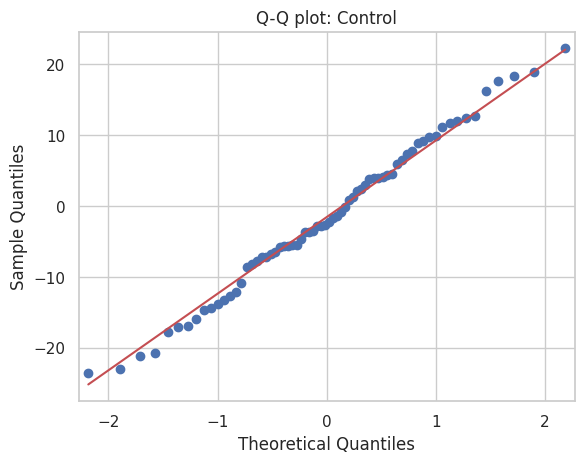

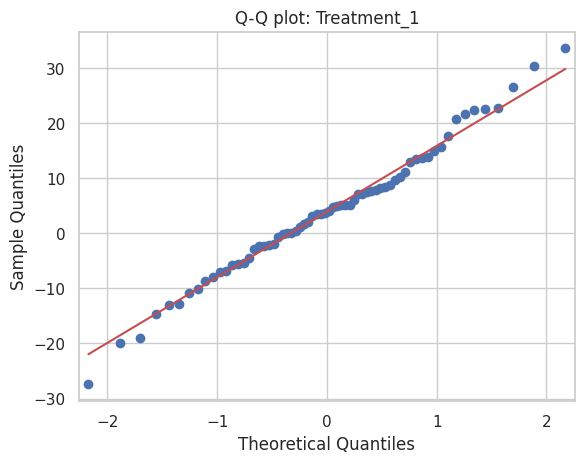

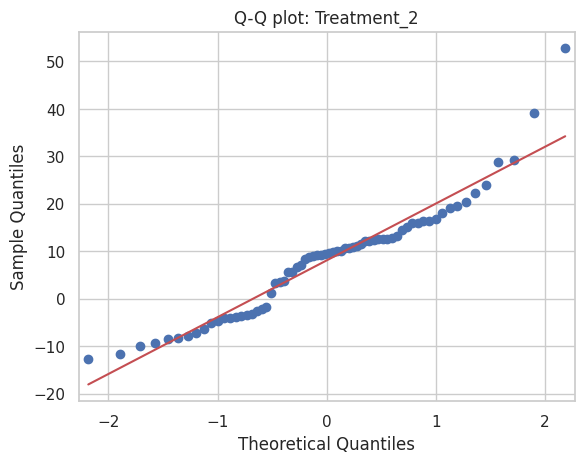

In [114]:

# Q-Q plots (visual)
import statsmodels.api as sm
for g in groups:
    sm.qqplot(df[df['group']==g]['outcome'].dropna(), line='s')
    plt.title(f'Q-Q plot: {g}')
    plt.show()


In [115]:
# Levene's test for equal variances
grouped = [df[df['group']==g]['outcome'].dropna() for g in groups]
lev_stat, lev_p = stats.levene(*grouped)
print('Levene stat=%.3f p=%.4f' % (lev_stat, lev_p))
# Interpretation
alpha = 0.05  # significance level

if lev_p > alpha:
    print("Levene's test Result: Fail to reject H0 → Variances are equal (assumption met).")
else:
    print("Levene's test Result: Reject H0 → Variances are not equal (assumption violated).")

Levene stat=0.039 p=0.9614
Levene's test Result: Fail to reject H0 → Variances are equal (assumption met).


###4. One-way Anova

In [116]:
# One-way ANOVA using statsmodels
model = smf.ols('outcome ~ C(group)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(group),3174.952568,2.0,11.66282,0.000016
Residual,27086.741467,199.0,NaN,NaN


In [117]:
# ANOVA result interpretation
# Extract statistics
F = anova_table.loc['C(group)', 'F']
p = anova_table.loc['C(group)', 'PR(>F)']
df1 = int(anova_table.loc['C(group)', 'df'])
df2 = int(anova_table.loc['Residual', 'df'])

# Effect size (eta squared)
eta2 = (
    anova_table.loc['C(group)', 'sum_sq'] /
    anova_table['sum_sq'].sum()
)

# Interpretation
sig = "Significant" if p < 0.05 else "Not significant"

effect = (
    "negligible" if eta2 < 0.01 else
    "small" if eta2 < 0.06 else
    "medium" if eta2 < 0.14 else
    "large"
)

print(
    f"ANOVA: F({df1}, {df2}) = {F:.2f}, "
    f"p = {p:.3f}, η² = {eta2:.3f}\n"
    f"Result: {sig} difference between groups "
    f"with a {effect} effect size."
)

if p < 0.05:
    print("→ Consider post-hoc testing (Tukey HSD).")

ANOVA: F(2, 199) = 11.66, p = 0.000, η² = 0.105
Result: Significant difference between groups with a medium effect size.
→ Consider post-hoc testing (Tukey HSD).


###5. Post-hoc Pairwise Comparison (Tukey HSD)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
    Control Treatment_1   5.4985  0.019  0.7381 10.2589   True
    Control Treatment_2   9.6318    0.0  4.9071 14.3566   True
Treatment_1 Treatment_2   4.1333 0.1031 -0.6271  8.8937  False
--------------------------------------------------------------


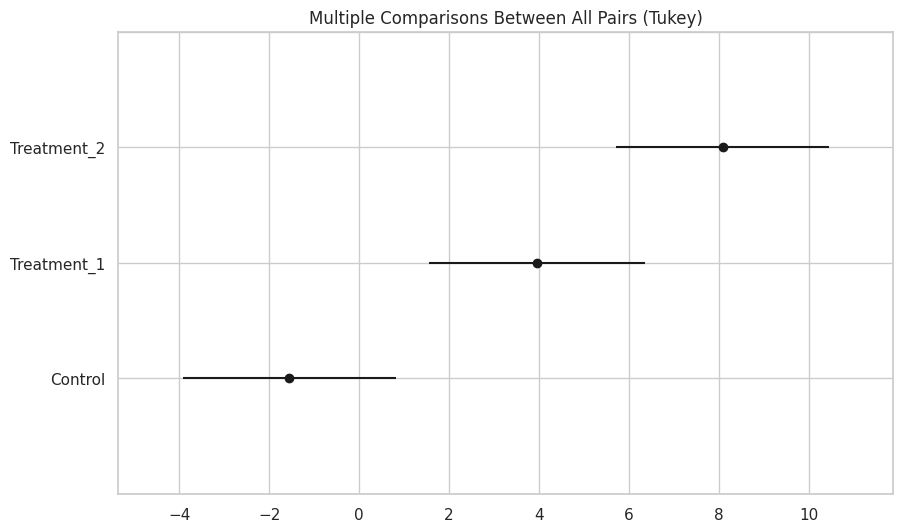

In [118]:
# Tukey HSD (pairwise)
df_clean = df.dropna(subset=['outcome'])
tukey = pairwise_tukeyhsd(endog=df_clean['outcome'], groups=df_clean['group'], alpha=0.05)
print(tukey)
tukey.plot_simultaneous()
plt.show()

In [119]:
# interpre Tukey test result
# Convert Tukey result to dataframe
tukey_df = pd.DataFrame(
    tukey.summary().data[1:],
    columns=tukey.summary().data[0]
)

print("\nTukey HSD Interpretation")
print("-" * 50)

for _, row in tukey_df.iterrows():

    g1 = row["group1"]
    g2 = row["group2"]
    diff = row["meandiff"]
    p = row["p-adj"]
    lower = row["lower"]
    upper = row["upper"]
    reject = row["reject"]

    if reject:
        print(
            f"{g1} vs {g2}: "
            f"Significant difference "
            f"(Mean diff = {diff:.2f}, "
            f"95% CI [{lower:.2f}, {upper:.2f}], "
            f"p = {p:.3f})"
        )
    else:
        print(
            f"{g1} vs {g2}: "
            f"No significant difference "
            f"(p = {p:.3f})"
        )


Tukey HSD Interpretation
--------------------------------------------------
Control vs Treatment_1: Significant difference (Mean diff = 5.50, 95% CI [0.74, 10.26], p = 0.019)
Control vs Treatment_2: Significant difference (Mean diff = 9.63, 95% CI [4.91, 14.36], p = 0.000)
Treatment_1 vs Treatment_2: No significant difference (p = 0.103)


###6.    Non-parametric Alternative - Kruskal-Wallis and Dunn
* When Assumptions are violated.

In [120]:
# Kruskal-Wallis test
kr_stat, kr_p = stats.kruskal(*[df[df['group']==g]['outcome'].dropna() for g in groups])

# Effect size (epsilon squared)
n = len(df['outcome'].dropna())
k = len(groups)

eps2 = (kr_stat - k + 1) / (n - k)

# Interpretation
sig = "Significant" if kr_p < 0.05 else "Not significant"

effect = (
    "negligible" if eps2 < 0.01 else
    "small" if eps2 < 0.08 else
    "medium" if eps2 < 0.26 else
    "large"
)

print(
    f"Kruskal-Wallis: H({k-1}) = {kr_stat:.2f}, "
    f"p = {kr_p:.3f}, ε² = {eps2:.3f}\n"
    f"Result: {sig} difference between groups "
    f"with a {effect} effect size."
)

if kr_p < 0.05:
    print("→ Consider post-hoc pairwise comparisons (Dunn's test).")


Kruskal-Wallis: H(2) = 20.28, p = 0.000, ε² = 0.092
Result: Significant difference between groups with a medium effect size.
→ Consider post-hoc pairwise comparisons (Dunn's test).


In [121]:
# Post-hoc Dunn test with Bonferroni
dunn = sp.posthoc_dunn(df_clean, val_col='outcome', group_col='group', p_adjust='bonferroni')
print(dunn)

print("Dunn's post-hoc (Bonferroni corrected)")
print("-" * 40)

for i in range(len(dunn.columns)):
    for j in range(i + 1, len(dunn.columns)):

        g1 = dunn.index[i]
        g2 = dunn.columns[j]
        p = dunn.iloc[i, j]

        result = (
            "Significant difference"
            if p < 0.05
            else "No significant difference"
        )

        print(f"{g1} vs {g2}: p = {p:.3f} → {result}")

              Control  Treatment_1  Treatment_2
Control      1.000000     0.031513     0.000022
Treatment_1  0.031513     1.000000     0.174343
Treatment_2  0.000022     0.174343     1.000000
Dunn's post-hoc (Bonferroni corrected)
----------------------------------------
Control vs Treatment_1: p = 0.032 → Significant difference
Control vs Treatment_2: p = 0.000 → Significant difference
Treatment_1 vs Treatment_2: p = 0.174 → No significant difference


###7. Reporting

In [122]:
# Generate Report

# Simple programmatic report
means = df_clean.groupby('group')['outcome'].mean()
print('\nGroup means:')
print(means.round(2))

# Brief textual summary
f_diff = means.max() - means.min()
print(f'Observed max-min mean difference across groups: {f_diff:.2f}')



Group means:
group
Control       -1.55
Treatment_1    3.95
Treatment_2    8.08
Name: outcome, dtype: float64
Observed max-min mean difference across groups: 9.63


**Disclaimer:**
This project is based on the course “Statistical Analysis and Data Modeling in Healthcare.” The original ideas and structure are adapted from the course materials, with additional code improvements and reorganized workflows for clarity, modularity, and better interpretability. The final implementation may differ from the original course version in structure and flow.

###**End Of Project**